In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics
# 插值
# import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata
# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist
# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

import os
import glob
import re

from importlib import reload  
  
reload(DE)
from DE import DESimulation


#给参数，都不用改
data = np.load(".//sim_config/cevns_sim.npz")
data_original = np.load("./sim_config/e_spectrum_relics.npz")
DE_sim = DESimulation('./sim_config/CEvNS_3-10.yaml')

muon_track_file_load_once = 1
param = 0

#读一个文件，这个文件会给定位置和能量，要生成延迟电子

muon_file_list = []
for i in range(muon_track_file_load_once):
    print(i)
    file_index = param * muon_track_file_load_once + i
    filename = DE_sim.muon_track_file + \
       "muon_track." + str(file_index) + ('.npy')
    # filename = "./muon_track/muon_track.0.npy"
    # print(filename)
    muon_file_list.append(filename)
    
DE_sim.generate_muon_points(muon_file_list)
DE_sim.generate_DE_points()
DE_sim.generate_Pile_UP_2e()
DE_sim.generate_Pile_UP_3e()
DE_sim.generate_Pile_UP_4e()
DE_sim.generate_Pile_UP_5e()
DE_sim.generate_Pile_UP_6e()
# DE_sim.generate_Pile_UP_7e()
# DE_sim.generate_Pile_UP_multi_e()
DE_sim.generate_DE_pattern_linear()
DE_sim.DE_position_recon()
DE_sim.generate_DE_recon_pattern()
DE_sim.DE_sp_cor()


Trans into torch tensor input
0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 135.86it/s]

./muon_track/muon_track.0.npy
Number of muon events: 3136
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
time range 305.8536585365854
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


Start sorting DE's time
Finish sorting DE's time
delayed_electron_sorted_in 6626048 [(   0,  35.16651322, 131.07713394, 3.26813823e-03, 2.41092543e-02)
 (   0,  36.0921875 , 130.90618045, 3.26813823e-03, 2.48489491e-02)
 (   0,  29.49157034, 134.37928936, 3.26813823e-03, 2.64974067e-02) ...
 (3135, -47.29547779, -15.93345025, 3.05652658e+02, 3.07651296e+02)
 (3135, -54.02877122,  22.76556285, 3.05652658e+02, 3.07651947e+02)
 (3135, -56.95523338, -83.95685992, 3.05652658e+02, 3.07652150e+02)]
fake_2e_event length 264500
fake_3e_event length 15263
fake_4e_event length 1129
fake_5e_event length 112
fake_6e_event length 9


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 7572.46it/s]


...

平均电子数：  3.9007094551753854
last_muon_id.shape:  (112,)
last_muon_id[-10:]:  [2856 2880 2937 2939 2985 3029 3043 3050 3082 3123]
0
0 112


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 112/112 [00:00<00:00, 11558.82it/s]


平均电子数：  4.886216190659283
last_muon_id.shape:  (9,)
last_muon_id[-10:]:  [  70  129  182 1114 1235 1388 1588 2599 3119]
0
0 9


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 8571.47it/s]

平均电子数：  6.082417027955341


In [2]:
def calculate_poisson_probabilities_log(data_array, mean_array):
    # 计算每个元素的对数概率
    log_probabilities = (
        -mean_array + data_array * np.log(mean_array) - gammaln(data_array + 1)
    )
    return log_probabilities


# test_DE_sim.pile_up_sp_cor
pile_up_sp_cor = np.log(np.concatenate(DE_sim.pile_up_sp_cor))
pile_up_e_num = []

for i in range(len(DE_sim.pile_up_e_num)):
    num_e = DE_sim.pile_up_e_num[i]
    pile_up_e_num.append(np.ones(len(DE_sim.pile_up_sp_cor[i])) * num_e)

pile_up_e_num = np.concatenate(pile_up_e_num)

pile_up_pattern = []
pile_up_area = []
pe_info_list = []
num_event = 0
for i in range(len(DE_sim.pile_up_e_num)):
    area_pattern = DE_sim.pile_up_pe_by_area[i]
    recon_pattern =DE_sim.pile_up_recons_light_pattern[i]
    pe_info = np.copy(DE_sim.pile_up_pe_info[i])
    print("pe_info['event_id']", pe_info["event_id"][-1])
    pe_info["event_id"] = pe_info["event_id"] + num_event
    print("pe_info['event_id']", pe_info["event_id"][-1])
    pe_info_list.append(pe_info)
    print("num of pattern: ", len(recon_pattern))
    print(num_event)
    num_event += len(recon_pattern)
    print(num_event)
    pattern = np.sum(
        calculate_poisson_probabilities_log(
            area_pattern[:, :64], recon_pattern[:, :64]
        ),
        axis=1,
    )
    pile_up_pattern.append(pattern)
    area = np.sum(area_pattern, axis=1)
    pile_up_area.append(area)

pile_up_pattern_coefficient = np.concatenate(pile_up_pattern)
pile_up_area = np.concatenate(pile_up_area)
area_pattern = np.concatenate(DE_sim.pile_up_pe_by_area)
pile_up_pe_info = np.concatenate(pe_info_list)

data_save = {"pile_up_pattern_coefficient": pile_up_pattern_coefficient}
data_save["pile_up_area"] = pile_up_area
data_save["area_pattern"] = area_pattern
data_save["pile_up_pe_info"] = pile_up_pe_info
data_save["pile_up_e_num"] = pile_up_e_num
data_save["pile_up_sp_cor"] = pile_up_sp_cor


# np.savez("DE_result_0822/" + str(index * file_load_once) + ".npz", **data_save)

pe_info['event_id'] 264499
pe_info['event_id'] 264499
num of pattern:  264500
0
264500
pe_info['event_id'] 15262
pe_info['event_id'] 279762
num of pattern:  15263
264500
279763
pe_info['event_id'] 1128
pe_info['event_id'] 280891
num of pattern:  1129
279763
280892
pe_info['event_id'] 111
pe_info['event_id'] 281003
num of pattern:  112
280892
281004
pe_info['event_id'] 8
pe_info['event_id'] 281012
num of pattern:  9
281004
281013


In [13]:
print(len(pile_up_area))
print(pile_up_area)

281013
[ 57.08545815  68.97554104  64.22865696 ... 200.55352884 204.3472537
 181.04986982]


In [14]:

print(pile_up_pattern_coefficient)
print(pile_up_sp_cor)

[ -53.48206711  -40.72724227  -53.69735912 ... -143.51618003 -143.39815923
  -76.19694083]
[11.91206537 11.95876126 11.92951659 ... 11.23185973 36.38524495
 10.97187433]


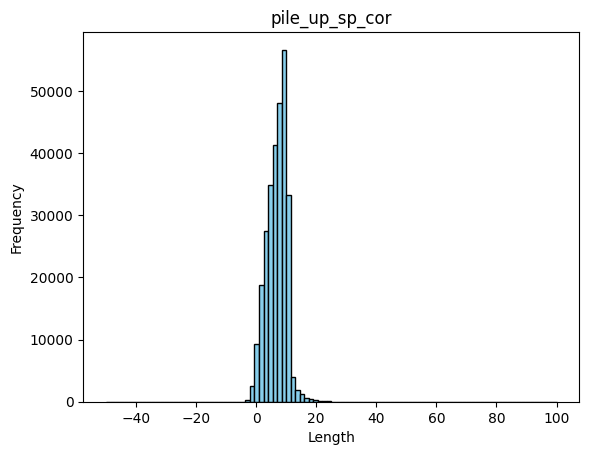

In [24]:
import matplotlib.pyplot as plt

# 假设 score 是您打印出的长度数据
# 生成边缘位置
bins = np.linspace(-50, 100, 101)  # 101 个边缘位置，分成 100 个 bin

# 绘制直方图
plt.hist(pile_up_sp_cor, bins=bins, color='skyblue', edgecolor='black')  # bins 参数指定直方图的条形数量
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('pile_up_sp_cor')
plt.show()

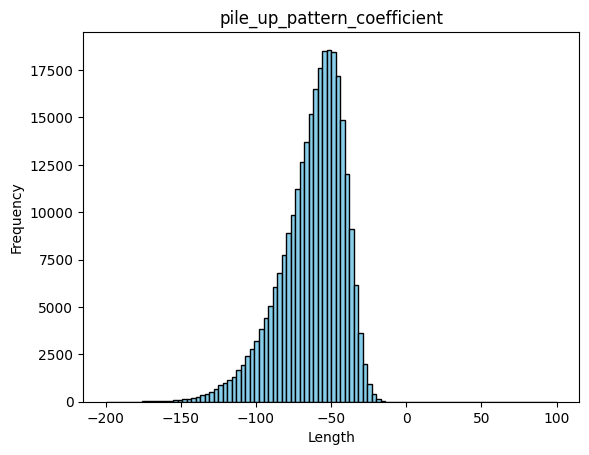

In [23]:
import matplotlib.pyplot as plt

# 假设 score 是您打印出的长度数据
# 生成边缘位置
bins = np.linspace(-200, 100, 101)  # 101 个边缘位置，分成 100 个 bin

# 绘制直方图
plt.hist(pile_up_pattern_coefficient, bins=bins, color='skyblue', edgecolor='black')  # bins 参数指定直方图的条形数量
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('pile_up_pattern_coefficient')
plt.show()

In [17]:
print("dense_muon_points data: ", DE_sim.dense_muon_points[:120])
print("dense_muon_points data type: ", DE_sim.dense_muon_points.dtype)
aa = DE_sim.dense_muon_points

dense_muon_points data:  [(0,  22.,  35.50886603, 133.14609447, -202.17887819, 0.00326814,  1119,  1)
 (0,  22.,  35.46592525, 133.10993122, -202.24272791, 0.00326814,  1119,  1)
 (0,  22.,  35.42298446, 133.07376798, -202.30657762, 0.00326814,  1119,  1)
 (0,  22.,  35.38004368, 133.03760473, -202.37042734, 0.00326814,  1119,  1)
 (0,  22.,  35.33710289, 133.00144149, -202.43427705, 0.00326814,  1119,  1)
 (0,  22.,  35.29416211, 132.96527824, -202.49812677, 0.00326814,  1119,  1)
 (0,  22.,  35.25122132, 132.929115  , -202.56197649, 0.00326814,  1119,  1)
 (0,  22.,  35.20828054, 132.89295176, -202.6258262 , 0.00326814,  1119,  1)
 (0,  22.,  35.16533975, 132.85678851, -202.68967592, 0.00326814,  1119,  1)
 (0,  22.,  35.12239896, 132.82062527, -202.75352563, 0.00326814,  1119,  1)
 (0,  22.,  35.07945818, 132.78446202, -202.81737535, 0.00326814,  1119,  1)
 (0,  22.,  35.03651739, 132.74829878, -202.88122506, 0.00326814,  1119,  1)
 (0,  22.,  34.99357661, 132.71213553, -202.9450747

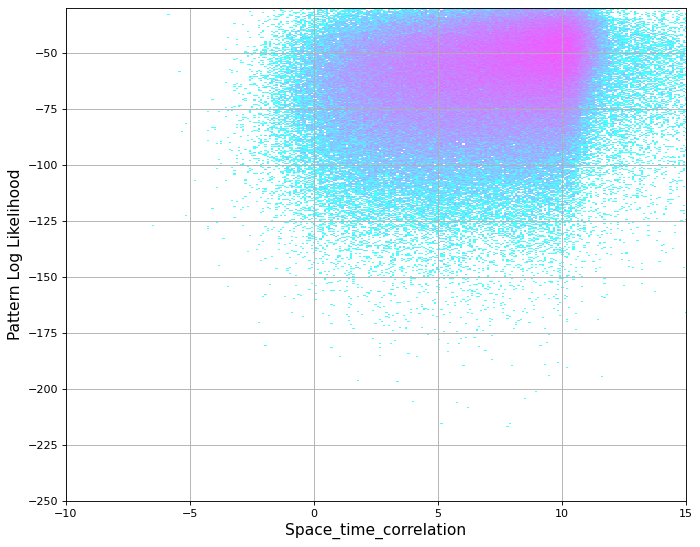

In [18]:
mask = np.isnan(pile_up_sp_cor) | np.isinf(pile_up_sp_cor)
mask |= np.isnan(pile_up_pattern_coefficient) | np.isinf(pile_up_pattern_coefficient)

pile_up_sp_cor_filtered = pile_up_sp_cor[~mask]
pile_up_pattern_coefficient_filtered = pile_up_pattern_coefficient[~mask]
pile_up_area_filtered = pile_up_area[~mask]
fig = plt.figure(figsize=(10, 8), dpi=80)
H = plt.hist2d(pile_up_sp_cor_filtered, pile_up_pattern_coefficient_filtered, bins=500, cmap='cool', norm=LogNorm(), alpha=0.7, label='DE Event')
plt.xlabel('Space_time_correlation', fontsize=14)
plt.ylabel('Pattern Log Likelihood', fontsize=14)
plt.xlim(-10, 15)
plt.ylim(-250, -30)
plt.grid()
plt.show()

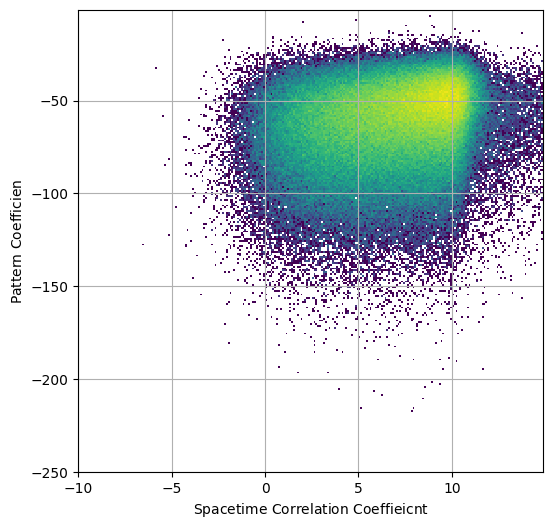

In [19]:
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

# roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)


plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)

# H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor_filtered, pile_up_pattern_coefficient_filtered,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
# plt.savefig("Pattern_dis.png")
plt.show()

In [20]:
k_st = 5.6
k_area= 0.8
b = -37.42

score_cevns = pile_up_pattern_coefficient_filtered - (k_st * pile_up_sp_cor_filtered) + k_area * pile_up_area_filtered + b
# score_cevns =pile_up_sp_cor_filtered - (k_st * pile_up_pattern_coefficient_filtered) + k_area * pile_up_area_filtered + b

# score_cevns = cevns_info_roi['pattern'] - (k_st * cevns_info_roi['st_cor']) + k_area * cevns_info_roi['area'] + b

In [21]:
cut_0 = score_cevns >0
print(score_cevns[cut_0])

[]


281012


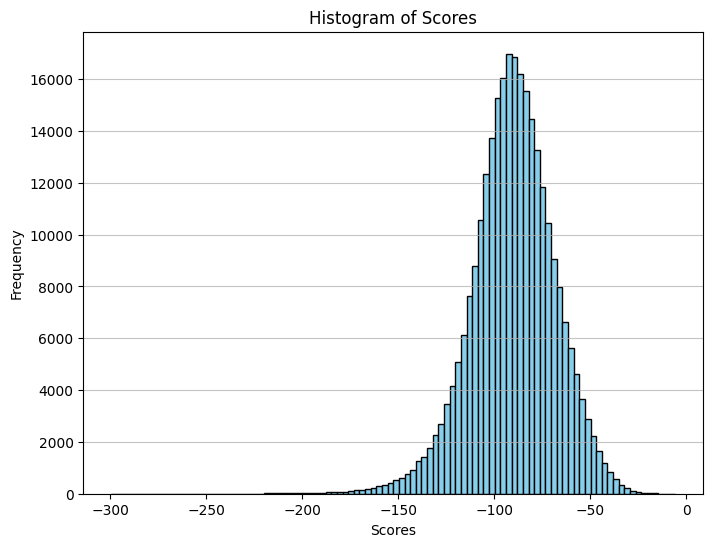

In [22]:
print(len(score_cevns))
import matplotlib.pyplot as plt

# 绘制直方图
plt.figure(figsize=(8, 6))
plt.hist(score_cevns, bins=100, color='skyblue', edgecolor='black')  # 指定bin数量和颜色
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Scores')
plt.grid(axis='y', alpha=0.75)  # 显示y轴网格线
plt.show()

In [12]:
print(score_cevns)


[ -92.66499091  -92.19340181 -100.17733736 ...  -96.7934335   -93.22216627
  -54.47973352]


In [13]:
print(len(pile_up_pattern_coefficient_filtered))
print(len(pile_up_sp_cor_filtered))
print(len(pile_up_sp_cor))


543265
543265
543267
